# ANALYSE DU TRAIL MI-HARD 

## I/ DATA ENGINEERING

The goal of this section is to have clean data to work with

In [1]:
import fitparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
fitfile = fitparse.FitFile('fitfiletools.fit')

data_points = []

for record in fitfile.get_messages('record'):
    record_data = {}
    for record_data_entry in record:
        record_data[record_data_entry.name] = record_data_entry.value
    data_points.append(record_data)


In [ ]:
df = pd.DataFrame(data_points)

# Latitude and Longitude conversion
conversion_factor = 180 / (2**31)
df['latitude'] = df['position_lat'] * conversion_factor
df['longitude'] = df['position_long'] * conversion_factor
df.drop(['position_lat', 'position_long'], axis=1, inplace=True)

# Timestamp conversion into datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')

# Data cleaning of "NAN" fields
print("Missing values before cleaning :")
print(df.isna().sum())

cols_to_fix = ['heart_rate', 'Effort Pace', 'enhanced_speed', 'speed', 'accumulated_power', 'power', 'altitude', 'enhanced_altitude', 'step_length', 'cadence','latitude', 'longitude']

for col in cols_to_fix:
    df[col] = df[col].interpolate(method='linear').ffill().bfill()

print('\n','-'*30)
print('\n', df.isna().sum())
print('data is now clean !')
df.describe()

Missing values before cleaning :
activity_type           0
distance                0
heart_rate              2
Effort Pace             4
enhanced_speed          3
speed                   4
accumulated_power       6
power                   6
altitude               38
enhanced_altitude       6
step_length             8
cadence                10
latitude             6717
longitude            6717
dtype: int64

 ------------------------------

 activity_type        0
distance             0
heart_rate           0
Effort Pace          0
enhanced_speed       0
speed                0
accumulated_power    0
power                0
altitude             0
enhanced_altitude    0
step_length          0
cadence              0
latitude             0
longitude            0
dtype: int64
data is now clean !


/var/folders/zm/vb45jb556xn4h93w3fzb9_c00000gn/T/ipykernel_28515/1458673437.py:20: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df[col] = df[col].interpolate(method='linear').ffill().bfill()


,distance,heart_rate,Effort Pace,speed,accumulated_power,power,altitude,step_length,cadence,latitude,longitude
count,41484.000000,41484.000000,41484.000000,41484.000000,4.148400e+04,41484.000000,41484.000000,41484.000000,41484.000000,41484.000000,41484.000000
mean,26637.178298,146.183733,2.147090,1.343430,3.116956e+06,141.810891,1736.768706,591.660640,58.935469,45.806197,6.707632
std,15126.162575,16.475703,0.962233,0.813566,1.597821e+06,67.655128,376.279454,284.721857,24.378818,0.026384,0.019688
min,0.000000,79.000000,0.000000,0.000000,2.000000e+00,0.000000,1126.000000,0.000000,0.000000,45.762812,6.659291
25%,13141.250000,143.000000,1.811000,0.803000,1.864727e+06,103.000000,1444.000000,430.000000,51.000000,45.785674,6.693676
50%,27205.250000,150.000000,2.330000,1.236000,3.206443e+06,156.000000,1748.000000,640.000000,58.000000,45.802673,6.708382
75%,38382.000000,157.000000,2.747000,1.953000,4.457456e+06,192.000000,1979.000000,800.000000,81.000000,45.825943,6.719986
max,54307.000000,175.000000,6.577000,3.447000,5.882661e+06,778.000000,2520.000000,1300.000000,109.000000,45.861665,6.754453


## II/ EXTRACTING KEY DATAS

### A. Time Spent At Aid Stations

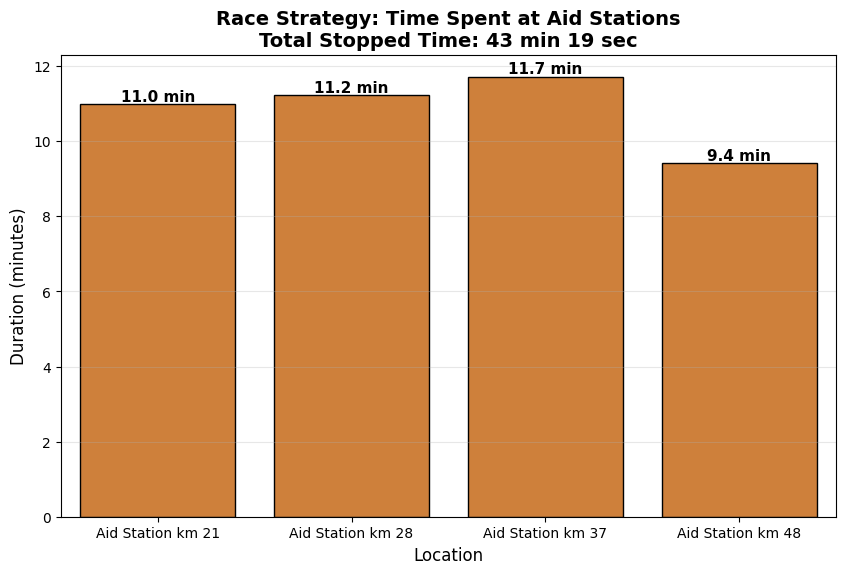

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. STOP DETECTION ---
# Speed threshold: Below 2 km/h, it is considered a stop at an aid station (ravito)
# (We use 2 and not 0 because the GPS always moves a little even when stationary)
stop_threshold_kmh = 2.0
min_duration_minutes = 5.0 # An aid station stop lasts at least 5 min (otherwise it's just a quick break or shoelace adjustment)

df_stops = df.copy()
# Assuming 'speed' is in m/s, convert to km/h
df_stops['speed_kmh'] = df_stops['speed'] * 3.6

# Create a boolean mask: True if you are stopped
df_stops['is_stopped'] = df_stops['speed_kmh'] < stop_threshold_kmh

# Use a pandas trick to group consecutive periods
# Each time the state (Stop/Run) changes, increment the 'group_id'
df_stops['group_id'] = (df_stops['is_stopped'] != df_stops['is_stopped'].shift()).cumsum()

# --- 2. DURATION CALCULATION ---
stops_list = []

# Iterate over each identified group
for group_id, group_data in df_stops.groupby('group_id'):
    # Only keep groups where the user was actually stopped
    if group_data['is_stopped'].iloc[0] == True:
        start_time = group_data.index[0]
        end_time = group_data.index[-1]
        duration = (end_time - start_time).total_seconds() / 60 # in minutes

        # Filter out "false stops" (quick pee break or technical bottleneck < 5 min)
        if duration >= min_duration_minutes:
            # Note the average kilometer point of the stop
            # Assuming 'distance' is in meters, convert to km
            km_point = group_data['distance'].mean() / 1000

            stops_list.append({
                'Aid Station (km)': km_point,
                'Duration (min)': duration,
                'Start Time': start_time,
                'End Time': end_time
            })

df_aid_stations = pd.DataFrame(stops_list)

# Round the kilometer for a clean label (e.g., "Aid Station km 15")
if not df_aid_stations.empty:
    df_aid_stations['Name'] = df_aid_stations['Aid Station (km)'].apply(lambda x: f"Aid Station km {int(round(x))}")

    # Calculate the total time spent at aid stations
    total_stop_time = df_aid_stations['Duration (min)'].sum()

    # --- 3. VISUALIZATION ---
    plt.figure(figsize=(10, 6))

    # Barplot of stop times
    ax = sns.barplot(
        data=df_aid_stations,
        x='Name',
        y='Duration (min)',
        color='#e67e22', # Orange "Warning"
        edgecolor='black'
    )

    # Calculate minutes and seconds for the title
    total_minutes = int(total_stop_time)
    total_seconds = int((total_stop_time % 1) * 60)

    plt.title(f"Race Strategy: Time Spent at Aid Stations\nTotal Stopped Time: {total_minutes} min {total_seconds} sec", fontsize=14, fontweight='bold')
    plt.ylabel("Duration (minutes)", fontsize=12)
    plt.xlabel("Location", fontsize=12)
    plt.grid(axis='y', alpha=0.3)

    # Annotate the values
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:.1f} min',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontweight='bold', fontsize=11)

    plt.show()

Good time managements skills there ! Very even repartition throughout the race. Maybe now it's time to shrink down the time spent at these aid station. 

### B. Walking Or Running ? That Is The Question

⚠️ Detected cadence in RPM (Cycles). Converting to SPM (x2)...


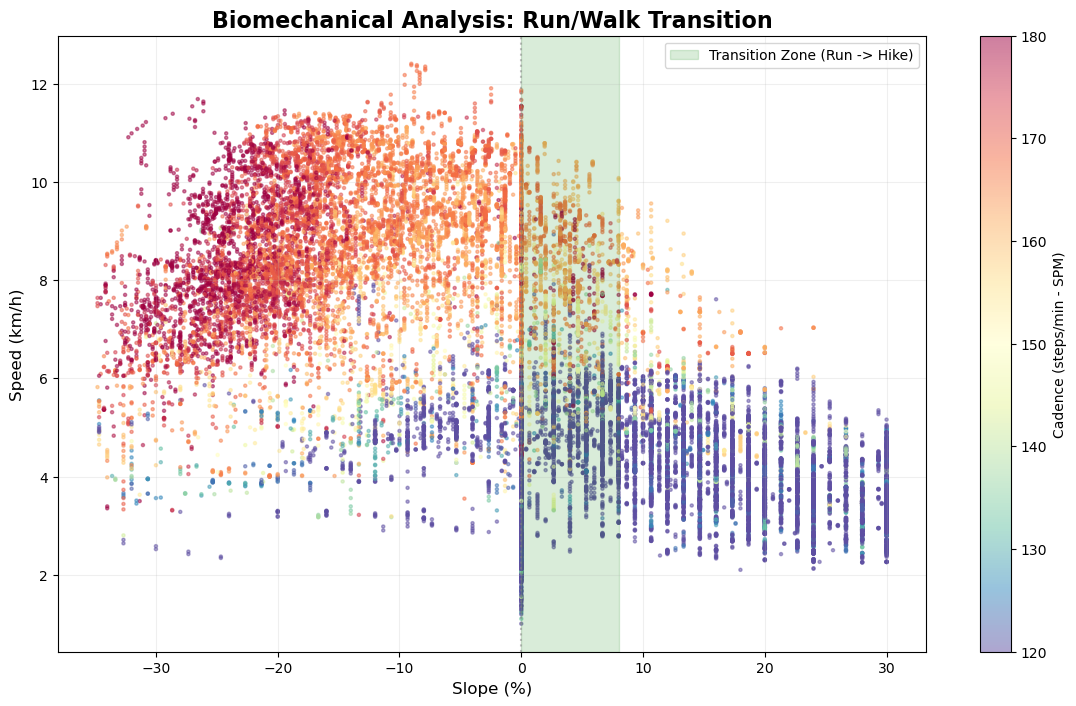

Corrected Max Cadence: 218.0 spm
Corrected Average Cadence: 131 spm


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. DATA CLEANING & FEATURE ENGINEERING ---
df_graph = df.copy()

# Calculate speed in km/h
df_graph['speed_kmh'] = df_graph['speed'] * 3.6

df['delta_alt'] = df['altitude'].diff()
df['delta_dist'] = df['distance'].diff()

df['delta_dist'] = df['delta_dist'].replace(0, np.nan)

df['slope_raw'] = (df['delta_alt'] / df['delta_dist']) * 100

df['slope_smooth'] = df['slope_raw'].rolling(window=25, center=True).mean()
df['slope_smooth'] = df['slope_smooth'].clip(-50, 30)
df['slope_smooth'] = df['slope_smooth'].fillna(0)


def calculate_energy_cost(slope_percent):
    # La pente doit être en fraction (ex: 10% -> 0.1)
    g = slope_percent / 100

    # Formule simplifiée du coût énergétique relative au plat (1.0 = plat)
    # C'est une courbe polynomiale qui augmente fort en montée
    cost = 155.4 * g**5 - 30.4 * g**4 - 43.3 * g**3 + 46.3 * g**2 + 19.5 * g + 3.6

    # Sur le plat, le coût est d'environ 3.6 J/kg/m. On normalise.
    return cost / 3.6

df['energy_cost'] = df['slope_smooth'].apply(calculate_energy_cost)

df['gap_speed'] = df['speed'] * df['energy_cost']

# Check if cadence is in "Cycles" (RPM) or "Steps" (SPM)
if df_graph['cadence'].median() < 100:
    print("⚠️ Detected cadence in RPM (Cycles). Converting to SPM (x2)...")
    df_graph['cadence'] = df_graph['cadence'] * 2
else:
    print("✅ Cadence already in SPM.")

# FILTERS: Keep a realistic range for a trail run
df_graph = df_graph[
    (df_graph['speed_kmh'] > 1) &
    (df_graph['slope_smooth'] > -35) &
    (df_graph['slope_smooth'] < 35) &
    (df_graph['speed_kmh'] < 25) &
    (df_graph['cadence'] > 30)
]

# --- 2. OPTIMIZED VISUALIZATION ---

plt.figure(figsize=(14, 8))

# Scatter Plot
points = plt.scatter(
    x=df_graph['slope_smooth'],
    y=df_graph['speed_kmh'],
    c=df_graph['cadence'], # Color is determined by cadence
    cmap='Spectral_r',     # Palette: Red (High) -> Blue (Low)
    s=5,                   # Point size
    alpha=0.5,             # Transparency
    vmin=120,              # Below 120 spm is fully blue (Walking)
    vmax=180               # Above 180 spm is fully red (Intense Running)
)


# Run/Walk transition zone
plt.axvspan(0, 8, color='green', alpha=0.15, label='Transition Zone (Run -> Hike)')

# --- 3. AESTHETICS ---
plt.colorbar(points, label='Cadence (steps/min - SPM)')
plt.title("Biomechanical Analysis: Run/Walk Transition", fontsize=16, fontweight='bold')
plt.xlabel("Slope (%)", fontsize=12)
plt.ylabel("Speed (km/h)", fontsize=12)
plt.grid(True, alpha=0.2)
plt.legend(loc='upper right')

plt.axvline(0, color='gray', linestyle=':', alpha=0.5)

plt.show()

print(f"Corrected Max Cadence: {df_graph['cadence'].max()} spm")
print(f"Corrected Average Cadence: {df_graph['cadence'].mean():.0f} spm")

Here we can observe the different phases: running and walking. We can see that during downhills I almost didn't walk but as soon as the slope flattened out running started to appear. The green zone is the transition zone, where I was doing as much walking as running. After this zone, I'm exclusively walking.

### C. Comparison between My Pace During the 5 climbs

/var/folders/zm/vb45jb556xn4h93w3fzb9_c00000gn/T/ipykernel_28515/1510580840.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  subset['alt_smooth'] = subset['altitude'].rolling(window=5, center=True).mean().fillna(method='bfill').fillna(method='ffill')
/var/folders/zm/vb45jb556xn4h93w3fzb9_c00000gn/T/ipykernel_28515/1510580840.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  subset['alt_smooth'] = subset['altitude'].rolling(window=5, center=True).mean().fillna(method='bfill').fillna(method='ffill')
/var/folders/zm/vb45jb556xn4h93w3fzb9_c00000gn/T/ipykernel_28515/1510580840.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  subset['alt_smooth'] = subset['altitude'].rolling(window=5, center=True).mean().fillna(method=

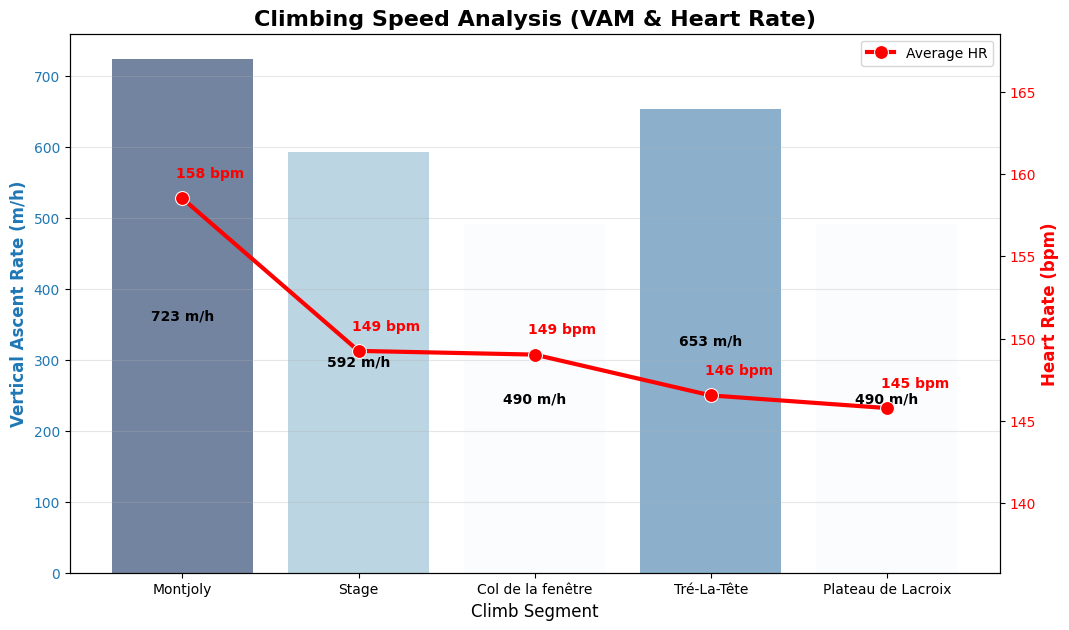

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CONFIGURATION ---
segments_config = [
    {'name': 'Montjoly', 'start_km': 0, 'end_km': 7.3},
    {'name': 'Stage', 'start_km': 23.5, 'end_km': 26.5},
    {'name': 'Col de la fenêtre', 'start_km': 28, 'end_km': 31.7},
    {'name': 'Tré-La-Tête', 'start_km': 36.7, 'end_km': 38.7},
    {'name': 'Plateau de Lacroix', 'start_km': 49.8, 'end_km': 51.7}
]

# 2. DATA CALCULATION
def calculate_cumulative_gain(series, threshold=0.5):
    diffs = series.diff()
    climbs = diffs[diffs > 0]
    return climbs.sum()

stats_list = []

for seg in segments_config:
    start_m = seg['start_km'] * 1000
    end_m = seg['end_km'] * 1000

    if start_m > df['distance'].max():
        continue

    # Find the nearest index for start and end points
    idx_start = (df['distance'] - start_m).abs().idxmin()
    idx_end = (df['distance'] - end_m).abs().idxmin()

    subset = df.loc[idx_start:idx_end].copy()

    if len(subset) > 10:
        # Smoothing and VAM calculation
        subset['alt_smooth'] = subset['altitude'].rolling(window=5, center=True).mean().fillna(method='bfill').fillna(method='ffill')
        elevation_gain_cumulative = calculate_cumulative_gain(subset['alt_smooth'])
        duration_hours = (subset.index[-1] - subset.index[0]).total_seconds() / 3600

        if duration_hours > 0:
            vam = elevation_gain_cumulative / duration_hours

            stats_list.append({
                'Climb': seg['name'],
                'VAM (m/h)': vam,
                'Avg HR (bpm)': subset['heart_rate'].mean(),
                'Elev Gain (m)': elevation_gain_cumulative
            })

df_vam = pd.DataFrame(stats_list)

# --- 3. COMBINED VISUALIZATION (DUAL AXIS) ---

if not df_vam.empty:
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # --- A. BARS (VAM) on the LEFT axis ---
    sns.barplot(
        data=df_vam,
        x='Climb',
        y='VAM (m/h)',
        hue='VAM (m/h)',
        palette='Blues',
        dodge=False,
        ax=ax1,
        alpha=0.6 # Transparency to let the red line stand out
    )

    # Remove automatic bar legend
    if ax1.get_legend():
        ax1.legend_.remove()

    ax1.set_ylabel("Vertical Ascent Rate (m/h)", color='#1f77b4', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#1f77b4')
    ax1.set_title('Climbing Speed Analysis (VAM & Heart Rate)', fontsize=16, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_xlabel('Climb Segment', fontsize=12)

    # --- B. LINE (HR) on the RIGHT axis ---
    ax2 = ax1.twinx() # Create a twin axis sharing the same X-axis

    sns.lineplot(
        data=df_vam,
        x='Climb',
        y='Avg HR (bpm)',
        color='red',
        marker='o',      # Round markers
        markersize=10,   # Large markers
        linewidth=3,     # Thick line
        ax=ax2,
        label='Average HR'
    )

    ax2.set_ylabel("Heart Rate (bpm)", color='red', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='red')

    # Adjust HR scale for better visualization
    min_hr = df_vam['Avg HR (bpm)'].min() - 10
    max_hr = df_vam['Avg HR (bpm)'].max() + 10
    ax2.set_ylim(min_hr, max_hr)

    # --- C. ANNOTATIONS ---
    # VAM values on the bars
    for p in ax1.patches:
        height = p.get_height()
        if np.isfinite(height) and height > 0:
            ax1.annotate(f'{int(height)} m/h',
                         (p.get_x() + p.get_width() / 2., height/2), # Center of the bar
                         ha='center', va='center', color='black', fontweight='bold')

    # HR values above the red points
    for i, row in df_vam.iterrows():
        ax2.annotate(f"{int(row['Avg HR (bpm)'])} bpm",
                     (i, row['Avg HR (bpm)']),
                     textcoords="offset points",
                     xytext=(20,15),
                     ha='center', color='red', fontweight='bold')

    plt.show()

My first climb is my best, maybe I should have started more cautiously. It's important to note that my climbing speed after this climb seems to be rather constant (between 500 and 650 m/h)

### D. Efficiency analysis during the race

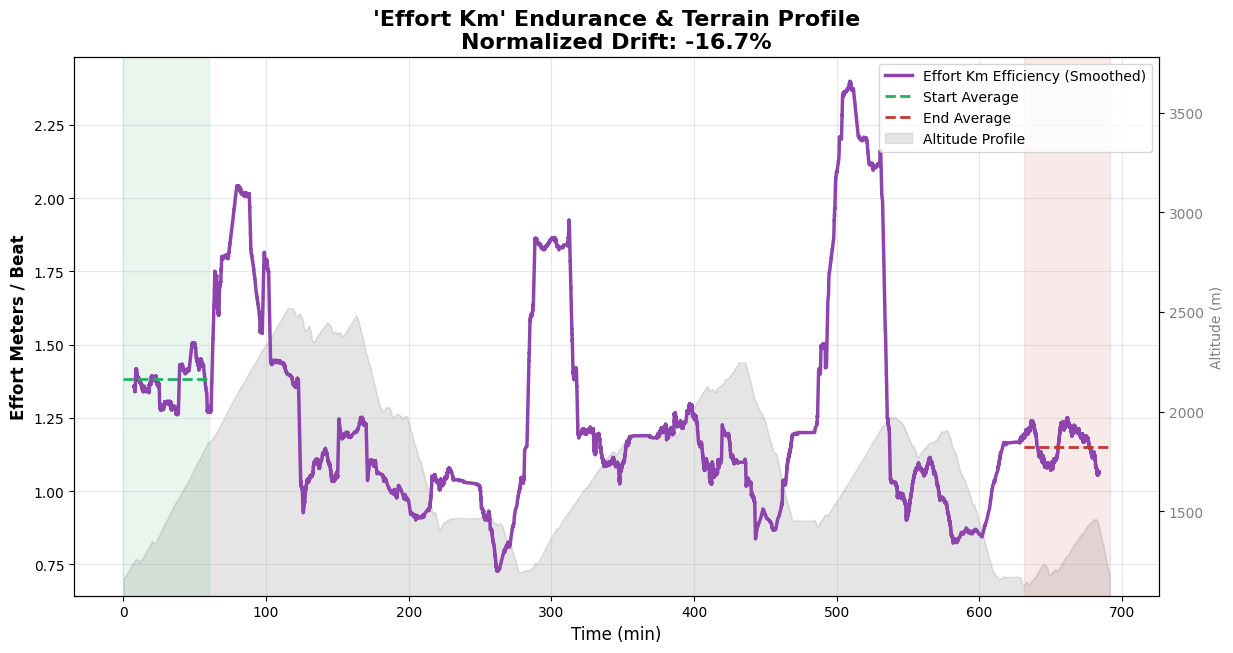

--- EFFORT KM ANALYSIS ---
Start: 1.38 effort-meters / beat
End: 1.15 effort-meters / beat
Drift: -16.67%


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. "EFFORT KILOMETER" CALCULATION ---
df_eff = df.copy()

# Calculate Elevation Gain (D+) and Effort Speed
df_eff['delta_alt'] = df_eff['altitude'].diff()
df_eff['gain_pos'] = df_eff['delta_alt'].clip(lower=0)

# Speed in m/min
real_speed_m_min = df_eff['speed'] * 60
# Effort bonus: Assuming 1m elevation gain = 10m flat distance
effort_bonus_m_min = (df_eff['gain_pos'] * 10) * 60
df_eff['effort_speed_m_min'] = real_speed_m_min + effort_bonus_m_min

# --- 2. EFFICIENCY RATIO CALCULATION ---

# Filters: Only consider active segments
mask_active = (df_eff['heart_rate'] > 40) & (df_eff['effort_speed_m_min'] > 50)
df_eff = df_eff[mask_active]

# Key Metric: Meters of Effort per Heart Beat
df_eff['efficiency_effort'] = df_eff['effort_speed_m_min'] / df_eff['heart_rate']

# Smoothing (900s = 15 min for a long-term trend)
df_eff['time_min'] = (df_eff.index - df_eff.index[0]).total_seconds() / 60
df_eff['ef_smooth'] = df_eff['efficiency_effort'].rolling(window=900, center=True).mean()

# --- 3. COMPARISON: FIRST HOUR vs LAST HOUR ---
total_time = df_eff['time_min'].max()
mask_first = (df_eff['time_min'] <= 60)
mask_last = (df_eff['time_min'] >= (total_time - 60))

# Mean efficiency for the first and last hour
avg_first = df_eff.loc[mask_first, 'efficiency_effort'].mean()
avg_last = df_eff.loc[mask_last, 'efficiency_effort'].mean()

# Percentage loss/drift
loss_pct = (avg_first - avg_last) / avg_first * 100

# --- 4. VISUALIZATION WITH TERRAIN (DUAL AXIS) ---

fig, ax1 = plt.subplots(figsize=(14, 7))

# --- BACKGROUND: TERRAIN PROFILE (Right Axis) ---
ax2 = ax1.twinx() # Create a twin axis sharing the same X-axis

# Plot the filled area for altitude
ax2.fill_between(
    df_eff['time_min'],
    df_eff['altitude'],
    color='gray',
    alpha=0.2, # Transparency
    label='Altitude Profile'
)

# Altitude Axis Aesthetics
ax2.set_ylabel('Altitude (m)', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')
ax2.grid(False) # Remove grid for altitude, keep the efficiency grid

# Adjust altitude scale to keep the curve low (visual trick)
alt_min = df_eff['altitude'].min()
alt_max = df_eff['altitude'].max()
# Force the y-axis to extend significantly upwards, compressing the altitude profile visually
ax2.set_ylim(alt_min - 50, alt_max * 1.5)

# --- FOREGROUND: EFFICIENCY (Left Axis) ---
sns.lineplot(
    data=df_eff,
    x='time_min',
    y='ef_smooth',
    color='#8e44ad',
    linewidth=2.5,
    label='Effort Km Efficiency (Smoothed)',
    ax=ax1 # Plot on the primary axis
)

# Mean Lines (On ax1)
ax1.hlines(avg_first, 0, 60, color='#27ae60', linestyle='--', linewidth=2, label='Start Average')
ax1.hlines(avg_last, total_time - 60, total_time, color='#c0392b', linestyle='--', linewidth=2, label='End Average')

# Highlighted Zones (On ax1)
ax1.axvspan(0, 60, color='#27ae60', alpha=0.1)
ax1.axvspan(total_time - 60, total_time, color='#c0392b', alpha=0.1)

# --- GENERAL AESTHETICS ---
# Ensure the efficiency line is above the altitude background (Z-Order)
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False) # Make the background of axis 1 transparent

plt.title(f"'Effort Km' Endurance & Terrain Profile\nNormalized Drift: -{loss_pct:.1f}%", fontsize=16, fontweight='bold')
ax1.set_xlabel("Time (min)", fontsize=12)
ax1.set_ylabel("Effort Meters / Beat", fontsize=12, fontweight='bold')

# Combined Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

ax1.grid(True, alpha=0.3)

plt.show()

print(f"--- EFFORT KM ANALYSIS ---")
print(f"Start: {avg_first:.2f} effort-meters / beat")
print(f"End: {avg_last:.2f} effort-meters / beat")
print(f"Drift: -{loss_pct:.2f}%")

Here I created a variable named "efficiency". It is formed by a distance (in km effort) divided by pulse. The higher it is, the more efficient I am.  Here we can see that I'm most efficient during climbs.  I also stayed approximately at the same efficiency during the whole race.

### E. Close up on two events

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- 1. PEAK IDENTIFICATION ---
# Find the exact moment of the 'hot flash' (Max HR)
time_peak = df['heart_rate'].idxmax()
max_hr = df['heart_rate'].max()

print(f"🔥 TARGET: HR Peak ({max_hr:.0f} bpm) reached at {time_peak}")

# --- 2. WINDOW ISOLATION (-45 minutes) ---
# Take the 45 minutes BEFORE the peak to observe the progressive degradation
start_window = time_peak - pd.Timedelta(minutes=45)
df_heat_buildup = df.loc[start_window:time_peak].copy()

# --- 3. THE MAGIC CALCULATION: ROLLING CORRELATION ---
# Calculate the correlation between GAP Speed and HR over a 5-minute rolling window.
# This shows "at every moment" how synchronized the two curves are.
df_heat_buildup['rolling_corr'] = df_heat_buildup['gap_speed'].rolling(window='5min').corr(df_heat_buildup['heart_rate'])


# --- 4. VISUALIZATION OF THE "DECOUPLING" ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# TOP GRAPH: RAW CURVES
ax1.set_title(f"Heat Stress Analysis: The Last 45 Minutes", fontsize=16, fontweight='bold')

# HR in Red
color_hr = '#e74c3c'
ax1.plot(df_heat_buildup.index, df_heat_buildup['heart_rate'], color=color_hr, label='Heart Rate', linewidth=2)
ax1.set_ylabel('HR (bpm)', color=color_hr, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_hr)
ax1.grid(True, alpha=0.3)

# GAP Speed in Blue (Right Axis)
ax1_speed = ax1.twinx()
color_speed = '#2980b9'
# Assuming 'gap_speed' is in m/s, convert to km/h
ax1_speed.plot(df_heat_buildup.index, df_heat_buildup['gap_speed']*3.6, color=color_speed, label='GAP Speed', alpha=0.6)
ax1_speed.set_ylabel('GAP Speed (km/h)', color=color_speed)
ax1_speed.tick_params(axis='y', labelcolor=color_speed)

# BOTTOM GRAPH: THE CORRELATION (THE PROOF)
# Correlation close to 1 = Everything is fine (Synchro)
# Dropping correlation = Problem (Decoupling)
ax2.plot(df_heat_buildup.index, df_heat_buildup['rolling_corr'], color='purple', linewidth=2, label='Rolling Correlation (5min)')

# Danger Zone (Correlation < 0)
# If the curve drops below zero, HR and Speed are moving in opposite directions!
ax2.fill_between(df_heat_buildup.index, df_heat_buildup['rolling_corr'], 0, where=(df_heat_buildup['rolling_corr'] < 0), color='red', alpha=0.3, label='Discordance Zone (Decoupling)')
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.axhline(0.8, color='green', linestyle=':', alpha=0.5, label='Good Synchro Threshold')

ax2.set_ylabel("Correlation Coefficient\n(1.0 = Perfect | <0 = Decoupling)", fontsize=10)
ax2.set_title("Physiological Decoupling: When the Heart No Longer Responds to Effort", fontsize=14, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# ANNOTATION 1: Point to the HR Peak
ax1.annotate('Overheating Peak',
             xy=(time_peak, max_hr),
             xytext=(-150, -30),
             textcoords='offset points',
             arrowprops=dict(facecolor='black', shrink=0.05, width=2),
             fontsize=10, fontweight='bold', color='black')

# ANNOTATION 2: Point to the worst decorrelation
min_corr_val = df_heat_buildup['rolling_corr'].min()
min_corr_time = df_heat_buildup['rolling_corr'].idxmin()

ax2.annotate('Worst Decoupling',
             xy=(min_corr_time, min_corr_val),
             xytext=(-150, 40),
             textcoords='offset points',
             arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=10),
             ha='center',
             fontsize=10, fontweight='bold', color='red')

plt.xlabel("Time")
plt.tight_layout()
plt.show()

🔥 TARGET: HR Peak (175 bpm) reached at 2025-07-05 09:13:04


KeyError: 'gap_speed'

Here we can very easily pinpoint my 2 weak moments at the start of the race: a back lock up (probably due to stress ) and at the end of the graph a complete overheat. I forgot to take my jacket off during downhill, causing myself to overheat completely.

## III/ What Are My Strenghts ?

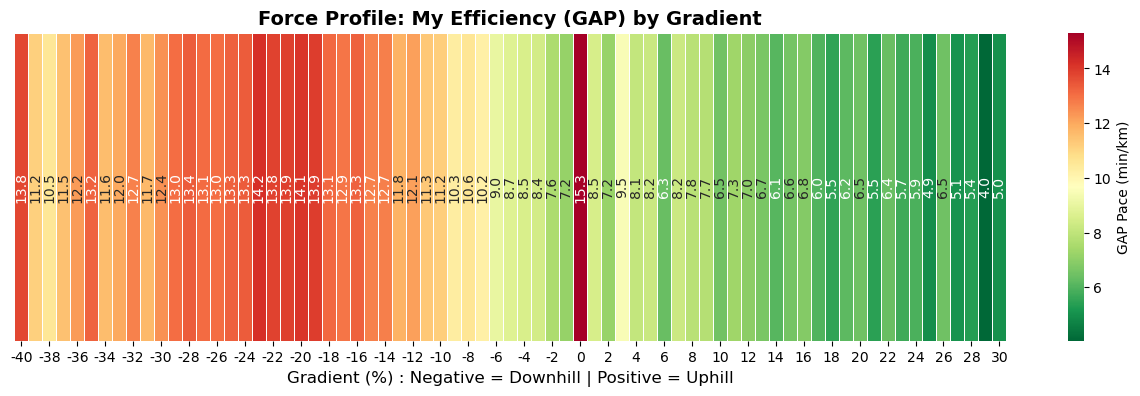

Correlation Coefficient (Gradient vs GAP Pace): -0.67


In [272]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. DATA PREPARATION ---
# Work on a copy
df_pace = df.copy()

# Conversion: Speed (m/s) -> GAP Pace (min/km)
# Assuming 'gap_speed' is in m/s, convert to km/h
df_pace['gap_kmh'] = df_pace['gap_speed'] * 3.6

# Calculate Pace: 60 / Speed
# Filter out outliers (pauses or GPS errors)
df_pace = df_pace[df_pace['gap_kmh'] > 3]
df_pace['gap_pace'] = 60 / df_pace['gap_kmh']

# Gradient Binning: Round to the nearest integer for grouping (e.g., 5.2% -> 5%)
df_pace['slope_bin'] = df_pace['slope_smooth'].round().astype(int)

# Filter to keep the useful zone (-40% to +40%)
df_viz = df_pace[(df_pace['slope_bin'] >= -40) & (df_pace['slope_bin'] <= 40)]

# --- 2. MATRIX CREATION (PIVOT TABLE) ---
# Group by slope and take the MEDIAN of your pace (more robust than the mean)
# Transpose (.T) to have the slopes on the horizontal axis
heatmap_data = df_viz.groupby('slope_bin')[['gap_pace']].median().T

# --- 3. VISUALIZATION (HEATMAP) ---
plt.figure(figsize=(16, 4))

# Create the Heatmap
# cmap='RdYlGn_r': Inverted Red-Yellow-Green Palette (_r)
# In running: Small number (e.g., 4:00/km) = Fast = Green. Large number = Slow = Red.
ax = sns.heatmap(
    heatmap_data,
    cmap='RdYlGn_r',
    annot=True,
    # Display the exact value (min/km) in the cell
    fmt=".1f",       # 1 decimal format
    cbar_kws={'label': 'GAP Pace (min/km)'},
    linewidths=0.5,  # Small space between cells
    square=False,
    annot_kws={"rotation": 90}
)

plt.title("Force Profile: My Efficiency (GAP) by Gradient", fontsize=14, fontweight='bold')
plt.xlabel("Gradient (%) : Negative = Downhill | Positive = Uphill", fontsize=12)
plt.yticks([]) # Hide the Y-axis which is not useful (single row)

plt.show()

# --- 4. STATISTICAL CORRELATION ---
# Calculate Pearson correlation coefficient between slope and pace
corr = df_viz[['slope_smooth', 'gap_pace']].corr().iloc[0, 1]
print(f"Correlation Coefficient (Gradient vs GAP Pace): {corr:.2f}")

Before we've seen that during the race peak efficiency was reached during clmimbs, it is confirmed by this graph showing my GAP per gradient. The steeper the climb is the better I seem to be. What I hadn't anticipated however was that my downhill pace would be this bad, I usually feel good during downhill and I consider it as one of my strength so this come as a suprise to me. This is probably due to the fact that the descents were very technical during this trail.